In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Load Datasets

In [3]:
apps = pd.read_csv(r'C:\Users\faraz\Downloads\google_cleaned (2).csv')

In [5]:
print (apps.shape)

(10840, 16)


In [6]:
apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Day,month,year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,15,1,2018
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,5000000,Free,0.0,Everyone,Art & Design,1.2.4,4.0.3 and up,1,8,2018
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,Varies with device,4.2 and up,8,6,2018
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,1.1,4.4 and up,20,6,2018


### 2. Data Cleaning

In [8]:
apps = apps.drop(columns=['Unnamed: 0'], errors='ignore')

print("Missing values:\n", apps.isnull().sum())

Missing values:
 App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Current Ver       0
Android Ver       0
Day               0
month             0
year              0
dtype: int64


In [9]:
print("\nData types:\n", apps.dtypes)


Data types:
 App                object
Category           object
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Current Ver        object
Android Ver        object
Day                 int64
month               int64
year                int64
dtype: object


In [10]:
def clean_installs(val):
    if isinstance(val, str):
        return int(val.replace(',', '').replace('+', '').strip()) if val.strip() != '' else np.nan
    return val

def clean_price(val):
    if isinstance(val, str):
        return float(val.replace('$', '').strip()) if val.strip() not in ('', '0') else 0.0
    return val

def clean_size(val):
    if isinstance(val, str):
        val = val.strip()
        if val.endswith('M'):
            return float(val[:-1]) * 1000  # convert to KB for consistency
        elif val.endswith('k'):
            return float(val[:-1])
        else:
            return np.nan  # e.g. "Varies with device"
    return val

if apps['Installs'].dtype == object:
    apps['Installs'] = apps['Installs'].apply(clean_installs)
if apps['Price'].dtype == object:
    apps['Price'] = apps['Price'].apply(clean_price)
if apps['Size'].dtype == object:
    apps['Size'] = apps['Size'].apply(clean_size)

# Handle nulls in Rating 
apps['Rating'] = apps.groupby('Category')['Rating'].transform(
    lambda x: x.fillna(x.median())
)
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

# Remove duplicate app entries 
apps = apps.sort_values('Reviews', ascending=False).drop_duplicates(subset='App', keep='first')

print("Shape after cleaning:", apps.shape)
print("Remaining missing values:\n", apps.isnull().sum())

Shape after cleaning: (9659, 15)
Remaining missing values:
 App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Current Ver       0
Android Ver       0
Day               0
month             0
year              0
dtype: int64


### 3. Category Analysis

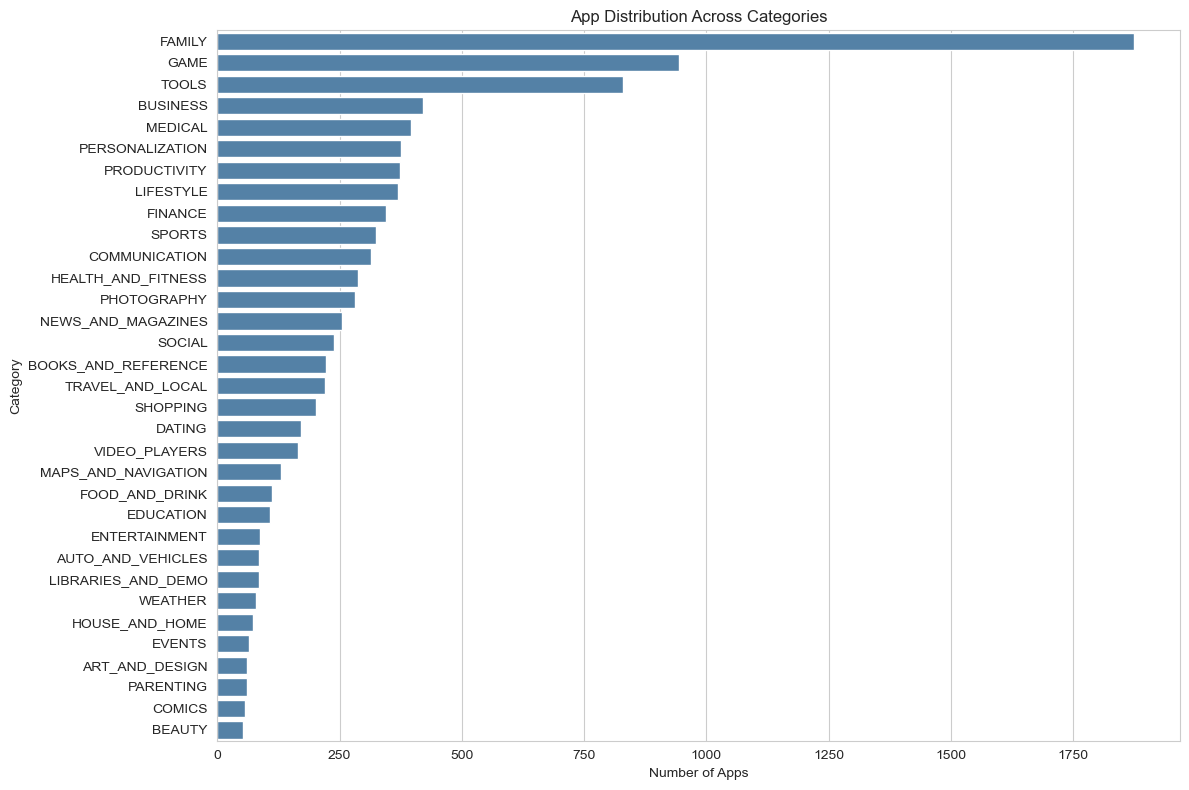

In [11]:
category_counts = apps['Category'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=category_counts.values, y=category_counts.index, color='steelblue')
plt.title('App Distribution Across Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

---------------

##### Based on the chart "App Distribution Across Categories," here is the quick story of the Android app market:

*The Big Three Dominate: The market is heavily saturated by just three major categories. Family apps are by far the most numerous (approaching 1,900 apps), followed closely by Game and Tools apps.*

*The Crowded Middle: A large block of practical and lifestyle categories—like Business, Medical, Personalization, Productivity, and Finance—maintain a steady, moderate presence, hovering roughly between 250 to 400 apps each.*

*The Niche Bottom: Highly specific or specialized categories see the lowest developer volume. Beauty, Comics, and Parenting sit at the very bottom, meaning they face far less competition but likely target much smaller audiences.*

-------------

In [15]:
print("Most saturated categories:")
print(category_counts.head(10))

Most saturated categories:
Category
FAMILY             1875
GAME                945
TOOLS               829
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


### 4. Ratings Analysis

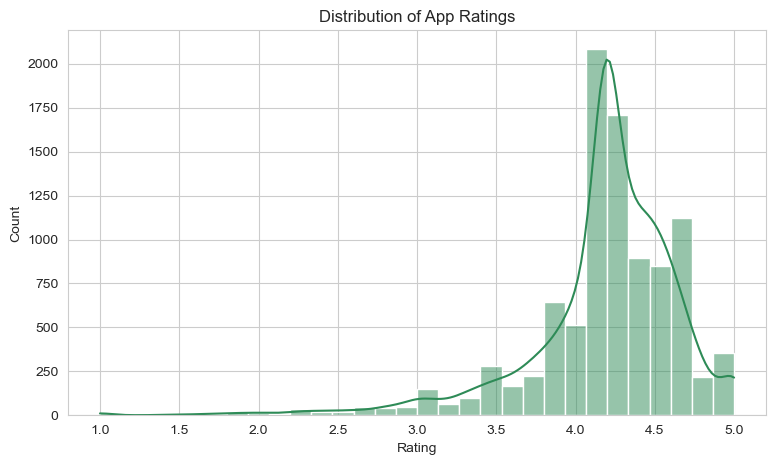

In [14]:
plt.figure(figsize=(9, 5))
sns.histplot(apps['Rating'], bins=30, kde=True, color='seagreen')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.show()

---------------

*The chart "Distribution of App Ratings" reveals that the Android app market is heavily skewed toward positive user feedback. Instead of a balanced curve centered around a 2.5 or 3.0 average, the distribution aggressively peaks between 4.2 and 4.3, where well over 2,000 apps sit. This left-skewed trend indicates a strong "feel-good" bias, showing that users are generally generous with their scores or that poorly performing apps are quickly filtered out. In fact, apps with ratings below 3.0 are incredibly rare, as the chart's left tail completely thins out. Ultimately, this data tells us that a 4.0 rating isn't an exceptional achievement—it's merely the baseline expectation. To truly stand out in this competitive landscape, a product must break past the crowd and secure a spot in the elite 4.5+ range.*

-------------------

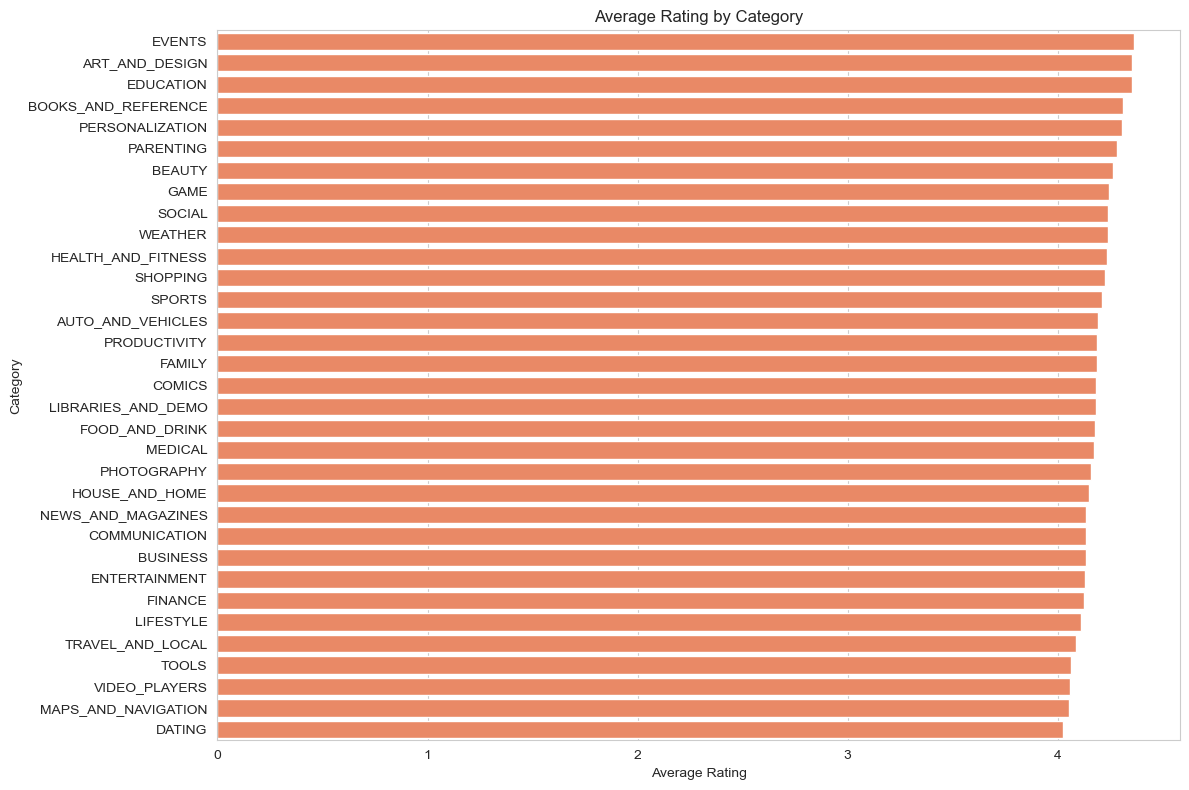

In [17]:
avg_rating_by_cat = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, color='coral')
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

-------------------

*The chart "Average Rating by Category" shows that across the entire Android market, user satisfaction remains remarkably high and uniform, with every single category maintaining an average score above 4.0. At the very top, niche and utility-focused categories like Events, Art & Design, and Education lead the pack with the highest average ratings, approaching 4.4. Conversely, more demanding or functionally complex categories like Dating, Maps & Navigation, and Tools sit at the bottom of the list, hovering closest to the 4.0 mark. Ultimately, the story here is one of tight competition: the gap between the highest-rated and lowest-rated app categories is incredibly narrow, proving that regardless of the niche, users expect a high baseline of quality everywhere.*

---------------

In [19]:
print(avg_rating_by_cat)

Category
EVENTS                 4.363178
ART_AND_DESIGN         4.353828
EDUCATION              4.353194
BOOKS_AND_REFERENCE    4.308393
PERSONALIZATION        4.303077
PARENTING              4.281960
BEAUTY                 4.260553
GAME                   4.241812
SOCIAL                 4.238926
WEATHER                4.238510
HEALTH_AND_FITNESS     4.235199
SHOPPING               4.226330
SPORTS                 4.211275
AUTO_AND_VEHICLES      4.190601
PRODUCTIVITY           4.185022
FAMILY                 4.184558
COMICS                 4.181848
LIBRARIES_AND_DEMO     4.181371
FOOD_AND_DRINK         4.174568
MEDICAL                4.172746
PHOTOGRAPHY            4.158191
HOUSE_AND_HOME         4.149330
NEWS_AND_MAGAZINES     4.135385
COMMUNICATION          4.134647
BUSINESS               4.133347
ENTERTAINMENT          4.129885
FINANCE                4.125060
LIFESTYLE              4.111489
TRAVEL_AND_LOCAL       4.087380
TOOLS                  4.060195
VIDEO_PLAYERS          4.058392

### 5. Size vs. Installs Analysis

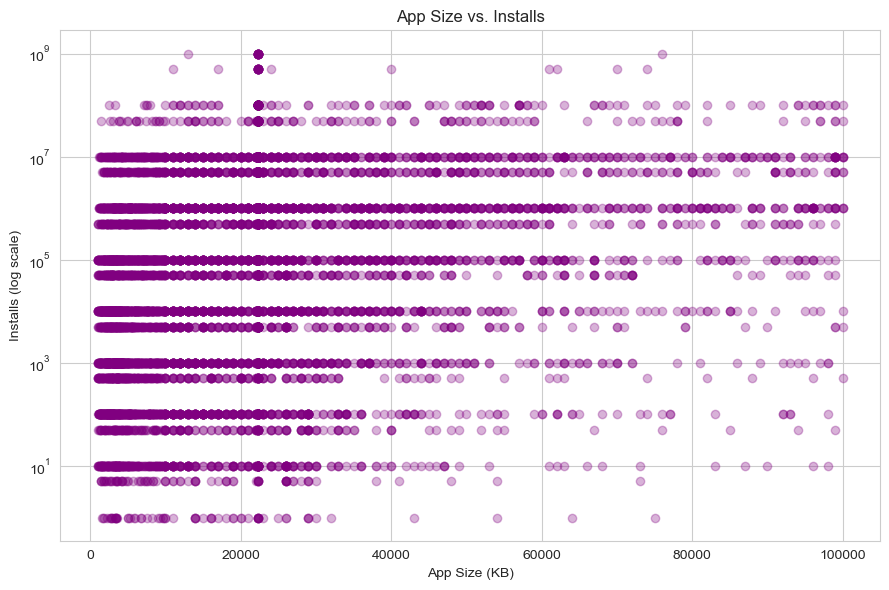

In [20]:
plt.figure(figsize=(9, 6))
plt.scatter(apps['Size'], apps['Installs'], alpha=0.3, color='purple')
plt.yscale('log')
plt.xlabel('App Size (KB)')
plt.ylabel('Installs (log scale)')
plt.title('App Size vs. Installs')
plt.tight_layout()
plt.show()

-----------------

*The scatter plot "App Size vs. Installs" shows that an app's file size does not dictate its market success, as high install counts are achieved by both small and large apps alike. The horizontal bands reveal that apps across the entire spectrum—from under 20,000 KB to the maximum 100,000 KB limit—can reach millions or even a billion ($10^9$) downloads. However, a noticeable density shift occurs in the lower size tiers; the vast majority of apps cluster under 40,000 KB, particularly peaking around a highly concentrated vertical strip near 22,000 KB. As app sizes push past 60,000 KB, the data points thin out considerably, indicating that while larger apps can still gain massive traction, developers generally prefer keeping their file sizes lean to appeal to a broader audience.*

--------------------

In [21]:
corr = apps[['Size', 'Installs']].corr().iloc[0, 1]
print(f"Correlation between Size and Installs: {corr:.4f}")

Correlation between Size and Installs: 0.0601


### 6. Pricing Analysis

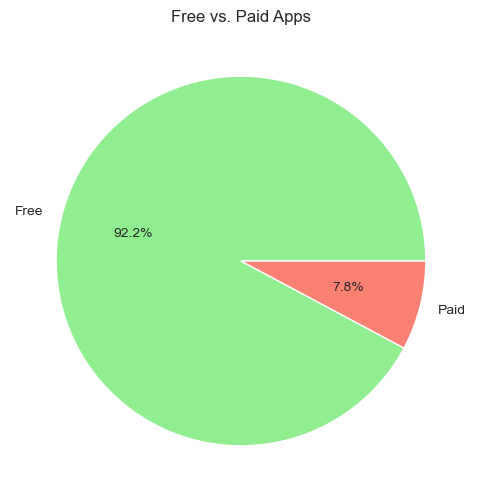

In [22]:
type_counts = apps['Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['lightgreen', 'salmon'])
plt.title('Free vs. Paid Apps')
plt.show()

-----------

*The pie chart "Free vs. Paid Apps" reveals an overwhelming preference for the freemium or ad-supported model in the Android app market. A massive 92.2% of all apps available on the platform are completely free to download, leaving paid apps as a tiny minority at just 7.8%. This stark contrast highlights a major market reality: users expect zero upfront costs when exploring new software. For developers, this means that launching a paid app comes with a significant barrier to entry, making alternative monetization strategies—such as in-app purchases, subscriptions, or advertisements—the definitive standard for achieving widespread reach and downloads.*

---------------------

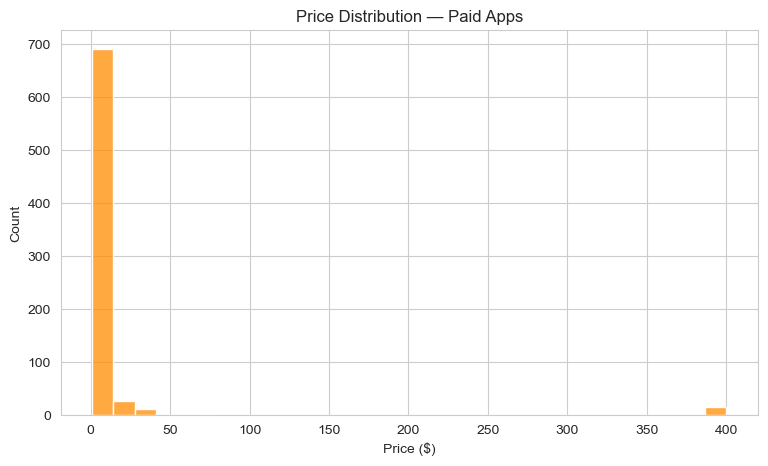

count    754.000000
mean      14.055902
std       58.821000
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


In [24]:
paid_apps = apps[apps['Type'] == 'Paid']

plt.figure(figsize=(9, 5))
sns.histplot(paid_apps['Price'], bins=30, color='darkorange')
plt.title('Price Distribution — Paid Apps')
plt.xlabel('Price ($)')
plt.show()

print(paid_apps['Price'].describe())

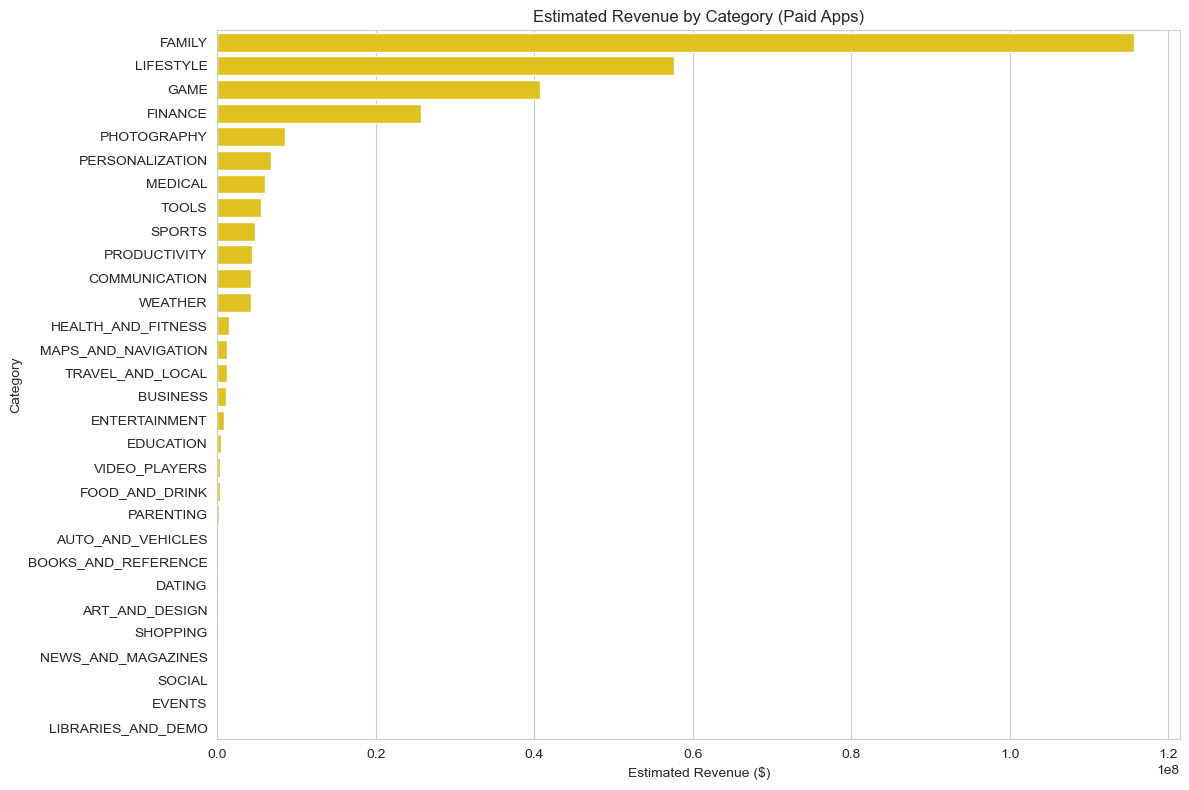

Category
FAMILY             1.156748e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.956237e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: EstRevenue, dtype: float64


In [25]:
paid_apps = paid_apps.copy()
paid_apps['EstRevenue'] = paid_apps['Price'] * paid_apps['Installs']

revenue_by_cat = paid_apps.groupby('Category')['EstRevenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=revenue_by_cat.values, y=revenue_by_cat.index, color='gold')
plt.title('Estimated Revenue by Category (Paid Apps)')
plt.xlabel('Estimated Revenue ($)')
plt.tight_layout()
plt.show()

print(revenue_by_cat.head(10))

-------------

*The bar chart illustrates the Estimated Revenue by Category for Paid Apps, revealing a highly concentrated market where a few select categories drive the vast majority of financial returns. Monetization through upfront paid downloads is exceptionally successful for specific user contexts (such as family and utility/lifestyle apps), while the remaining market exhibits a steep "long tail" effect with negligible paid revenue*

--------------

### 7. Sentiment Analysis on User Reviews

In [28]:
#!pip install textblob

In [29]:
def rating_to_sentiment(rating):
    if rating >= 4.0:
        return 'Positive'
    elif rating >= 3.0:
        return 'Neutral'
    else:
        return 'Negative'

apps['Sentiment'] = apps['Rating'].apply(rating_to_sentiment)
print(apps['Sentiment'].value_counts())

Sentiment
Positive    7750
Neutral     1631
Negative     278
Name: count, dtype: int64


### 8. Sentiment by Category

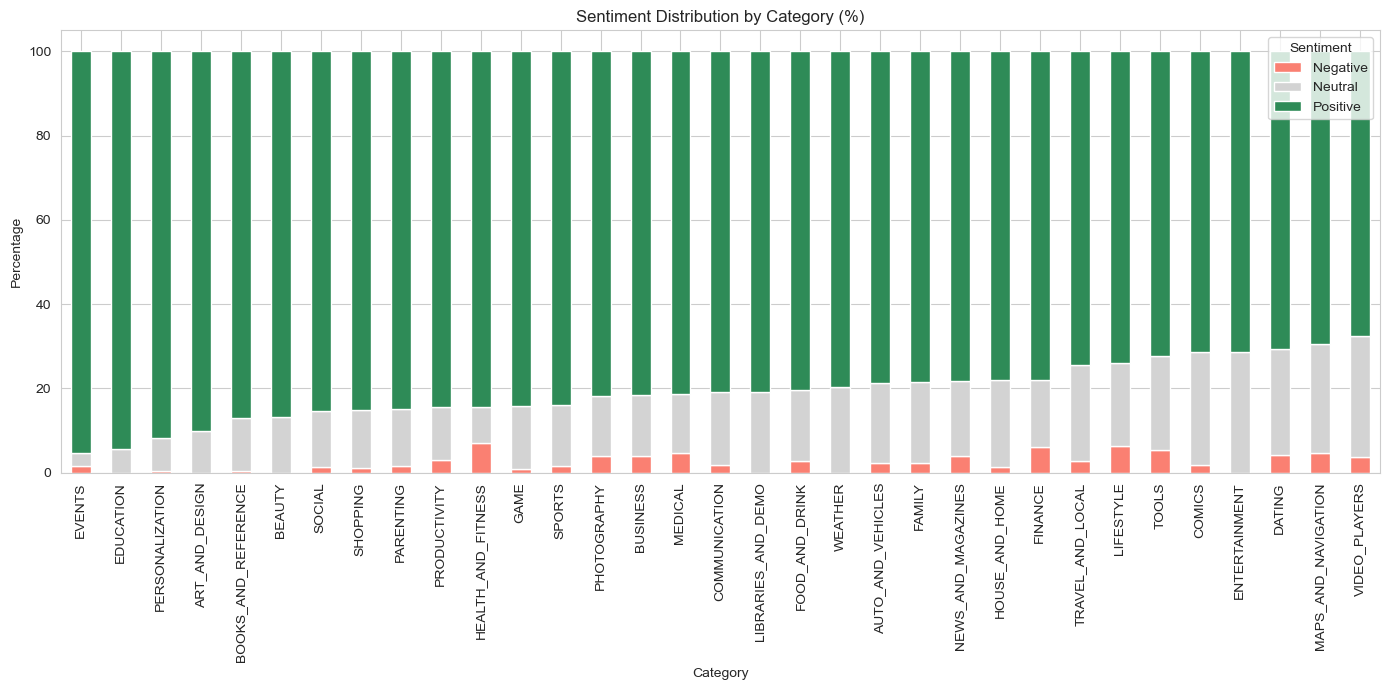

Sentiment            Negative    Neutral   Positive
Category                                           
EVENTS               1.562500   3.125000  95.312500
EDUCATION            0.000000   5.607477  94.392523
PERSONALIZATION      0.265957   7.978723  91.755319
ART_AND_DESIGN       0.000000   9.836066  90.163934
BOOKS_AND_REFERENCE  0.450450  12.612613  86.936937
BEAUTY               0.000000  13.207547  86.792453
SOCIAL               1.255230  13.389121  85.355649
SHOPPING             0.990099  13.861386  85.148515
PARENTING            1.666667  13.333333  85.000000
PRODUCTIVITY         2.941176  12.566845  84.491979


In [30]:
sentiment_by_cat = apps.groupby(['Category', 'Sentiment']).size().unstack(fill_value=0)
sentiment_pct = sentiment_by_cat.div(sentiment_by_cat.sum(axis=1), axis=0) * 100

sentiment_pct.sort_values('Positive', ascending=False).plot(
    kind='bar', stacked=True, figsize=(14, 7),
    color=['salmon', 'lightgrey', 'seagreen']
)
plt.title('Sentiment Distribution by Category (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=90)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

print(sentiment_pct.sort_values('Positive', ascending=False).head(10))

------------------

*The visual analysis evaluates user sentiment (Positive, Neutral, and Negative) across various app categories. The most prominent takeaway is the overwhelmingly positive sentiment across the entire application ecosystem, with positive reviews consistently capturing 65% to 95% of the total share for almost every category. Negative sentiment represents a minor fraction of overall user feedback, though specific utility and entertainment segments see slightly higher friction.*

------------------

### 9. Interactive Visualization (Plotly)

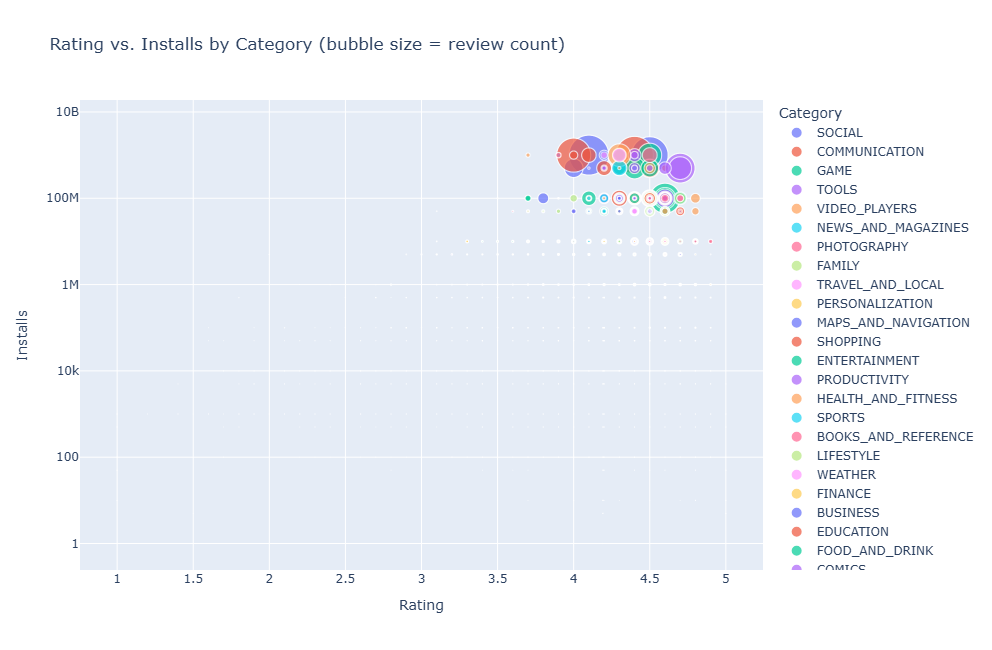

In [31]:
import plotly.express as px

fig = px.scatter(
    apps, x='Rating', y='Installs', size='Reviews', color='Category',
    hover_name='App', log_y=True, size_max=40,
    title='Rating vs. Installs by Category (bubble size = review count)'
)
fig.update_layout(height=650)
fig.show()

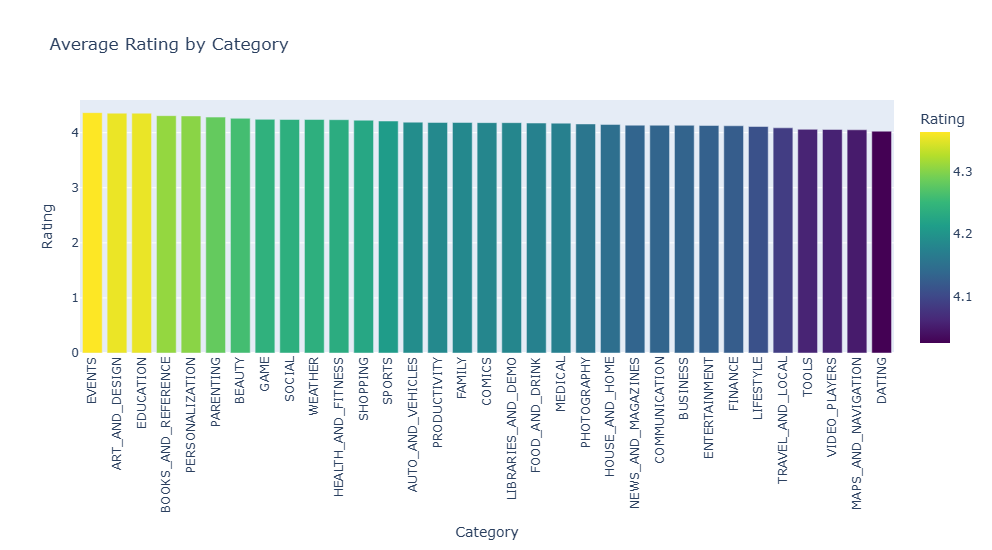

In [32]:
fig2 = px.bar(
    avg_rating_by_cat.reset_index(), x='Category', y='Rating',
    title='Average Rating by Category', color='Rating',
    color_continuous_scale='Viridis'
)
fig2.update_layout(xaxis_tickangle=-90, height=550)
fig2.show()

## Conclusion — 3 Data-Driven Insights for a New App Launch

1. **Category saturation vs. opportunity**: [Fill in from your output — e.g. FAMILY and GAME
   categories are the most saturated (highest app counts), meaning higher competition. Categories
   with fewer apps but solid average ratings (check `avg_rating_by_cat` combined with
   `category_counts`) may represent under-served niches worth targeting.

2. **Free-to-paid economics**: The vast majority of apps (~93%) are free, and paid apps cluster
   at low price points (check `paid_apps['Price'].describe()`). A freemium model with in-app
   purchases is likely more aligned with market norms than an upfront paid model, unless
   targeting a category with historically higher paid-app tolerance.

3. **Size doesn't strongly predict installs**: The weak correlation between Size and Installs
   suggests app size is not a major driver of adoption — investment is better spent on ASO
   (App Store Optimization), category selection, and rating/review quality than on minimizing
   app size alone.